### Lab 03: LOGISTIC REGRESSION

### **Student Information**

- **Name:** Abdullah Farooq
- **Roll_no:** 24F-AI-050

#### Lab Tasks:

- Import Required Libraries
- Load Dataset
  * Use a dataset Breast Cancer Dataset from sklearn.datasets.
- Exploratory Data Analysis (EDA)
  * Display first few rows of the dataset.
  * Check for missing values.
  * Plot histograms or distribution of features.
  * Check class distribution (malignant vs. benign).
- Data Preprocessing
  * Split features and labels.
  * Standardize features using StandardScaler.
  * Train-test split.
- Model Implementation
  * Use sklearn.linear_model.LogisticRegression.
  * Train the model on the training data.
  * Predict on the test data.
- Evaluation
  * Accuracy score.
  * Confusion matrix.
  * Precision, Recall, F1-score.

In [1]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Set plot style
sns.set_theme(style="whitegrid")

In [3]:
# 2. Load Dataset

# Use the Breast Cancer Dataset from sklearn.datasets
cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target # 0: Malignant, 1: Benign

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


0


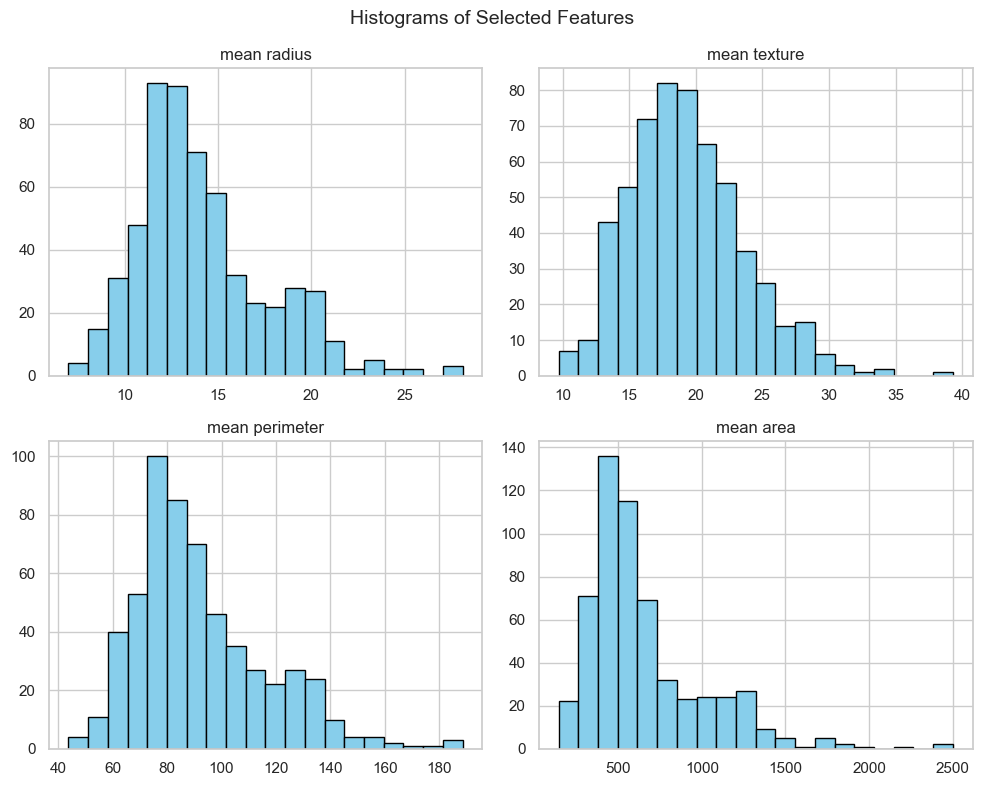

C:\Users\hp\AppData\Local\Temp\ipykernel_9852\2767321727.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='Set2')


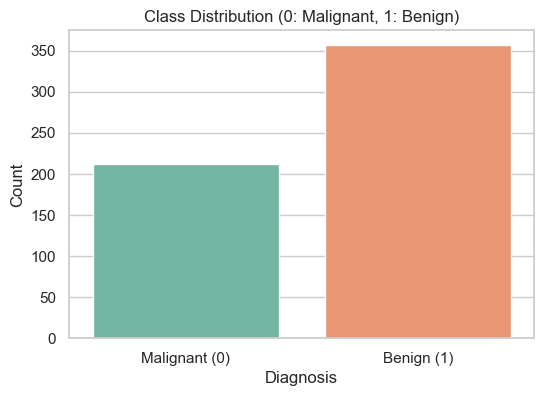

In [4]:
# 3. Exploratory Data Analysis (EDA)

# Display first few rows of the dataset
display(df.head()) 

# Check for missing values
print(df.isnull().sum().sum())

# Plot histograms or distribution of features (selecting a few for visibility)
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
df[features_to_plot].hist(figsize=(10, 8), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Selected Features', fontsize=14)
plt.tight_layout()
plt.show()

# Check class distribution (malignant vs. benign)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='Set2')
plt.title('Class Distribution (0: Malignant, 1: Benign)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Malignant (0)', 'Benign (1)'])
plt.show()

In [5]:
# 4. Data Preprocessing

# Split features and labels
X = df.drop(columns=['target'])
y = df['target']

# Train-test split (Standard practice is to split before scaling to prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# 5. Model Implementation

# Use sklearn.linear_model.LogisticRegression
model = LogisticRegression()

# Train the model on the training data
model.fit(X_train_scaled, y_train)

# Predict on the test data
y_pred = model.predict(X_test_scaled)

Accuracy Score: 0.9737



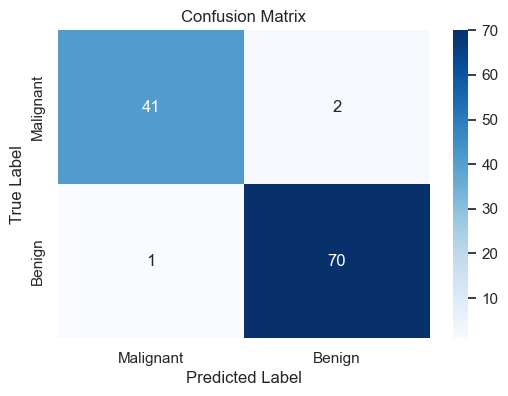

--- Classification Report ---
               precision    recall  f1-score   support

Malignant (0)       0.98      0.95      0.96        43
   Benign (1)       0.97      0.99      0.98        71

     accuracy                           0.97       114
    macro avg       0.97      0.97      0.97       114
 weighted avg       0.97      0.97      0.97       114



In [8]:
# 6. Evaluation

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}\n")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Precision, Recall, F1-score
print("--- Classification Report ---")
# The classification report automatically calculates precision, recall, and f1-score
print(classification_report(y_test, y_pred, target_names=['Malignant (0)', 'Benign (1)']))